## INSTRUCTIONS TO PLAY WITH THE HANDSOMEST ELF OF THEM ALL

![](/home/m.jaraiz/repos/fellowship-of-the-ring/pictures/legolas.jpg)


LEGOLAS can be instantianted passing it a FRODO database and is divided in four submodules, each responsible for a different display domain:


```python
leg = LEGOLAS(db)

leg.fields      # variables de campo (Cp, velocidad, etc.) del data_dict
leg.residuals   # residuales y métricas de convergencia
leg.params      # espacio de diseño (design_vars)
leg.state       # estado de completitud de los casos

In [1]:
from FotR import LEGOLAS, FRODO

def read_db(datafolder, case_idx):
    db = FRODO(root_dir = datafolder, format = 'CODA', initial_parse = True)
    
    db.extract_inputs(
        id_groups = (3,),
        cases_idx = case_idx,
        vtu_type='surface',
        verbose=False
        )

    db.extract_outputs(
        id_groups=(3,),
        stage=0, cases_idx = case_idx,
        var_name_excluded = [
            'BoundaryValues_CoefSkinFrictionX',
            'BoundaryValues_CoefSkinFrictionY',
            'BoundaryValues_CoefSkinFrictionZ'
            ],
        vtu_type='surface',
        )

    db.extract_outputs(
        id_groups=(3,),
        stage=1, cases_idx = case_idx,
        var_name_excluded = [
            'BoundaryValues_CoefSkinFrictionX',
            'BoundaryValues_CoefSkinFrictionY',
            'BoundaryValues_CoefSkinFrictionZ'
            ],
        vtu_type='surface',
        )

    leg = LEGOLAS(db)
    
    return db, leg

In [3]:
# Base de datos original
# case_idx = list(range(100))
# fuera = [64, 79, 87, 88, 94]
# for c in fuera:
#     case_idx.remove(c)
case_idx = list(range(10))
db_0, leg = read_db(datafolder='/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3/', case_idx=case_idx)


 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3
100 simulations found.
Parse taked: 0.0605 seconds


In [4]:
leg.fields.list_available_variables()

Available CADGroups and variables:

[CADGroup_3]
  Stage 0: ['GlobalNumber', 'CADGroupID', 'BoundaryValues_CoefPressure', 'BoundaryValues_CoefSkinFrictionTangential', 'BoundaryValues_YPlusFirstCell']
  Stage 1: ['GlobalNumber', 'CADGroupID', 'BoundaryValues_CoefPressure', 'BoundaryValues_CoefSkinFrictionTangential', 'BoundaryValues_YPlusFirstCell']


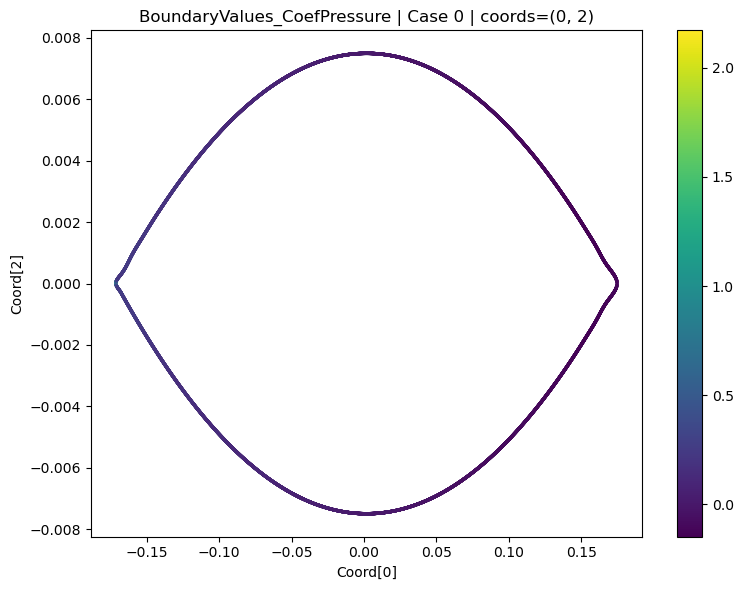

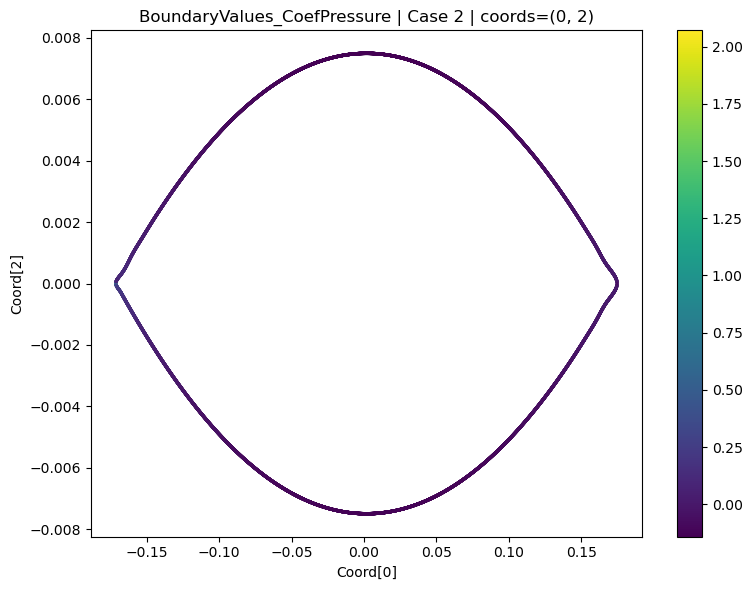

In [8]:
# El grupo y stage activos ya son CADGroup_3 y "0" por defecto
leg.fields.plot_field(var_name='BoundaryValues_CoefPressure', case_idx=0, coord_idx=(0, 2))

# Si quieres el stage 1 sin cambiar el activo permanentemente:
leg.fields.plot_field(
    var_name='BoundaryValues_CoefPressure',
    case_idx=2,
    stage=1,
    coord_idx=(0, 2)
)